In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
plots_dir <- "../../../../paper_figures/"

### Cardiomyocyte

In [3]:
CM_subsampled_results_df <- read.csv("Cardiomyocyte_deg_results_subsampling.csv")
CM_subsampled_results_df %>% head()

,num_subsample,aging_up_DEGs,aging_down_DEGs,disease_up_DEGs,disease_down_DEGs,sex_up_DEGs,sex_down_DEGs,replicate
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,50,0,1,142,324,25,9,1
2,50,37,31,76,113,14,7,2
3,50,64,118,452,300,30,11,3
4,50,0,0,255,204,16,7,4
5,50,1,0,177,69,14,5,5
6,75,34,24,600,533,35,16,1


In [4]:
colnames(CM_subsampled_results_df)

[1] "num_subsample"     "aging_up_DEGs"     "aging_down_DEGs"  
[4] "disease_up_DEGs"   "disease_down_DEGs" "sex_up_DEGs"      
[7] "sex_down_DEGs"     "replicate"

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


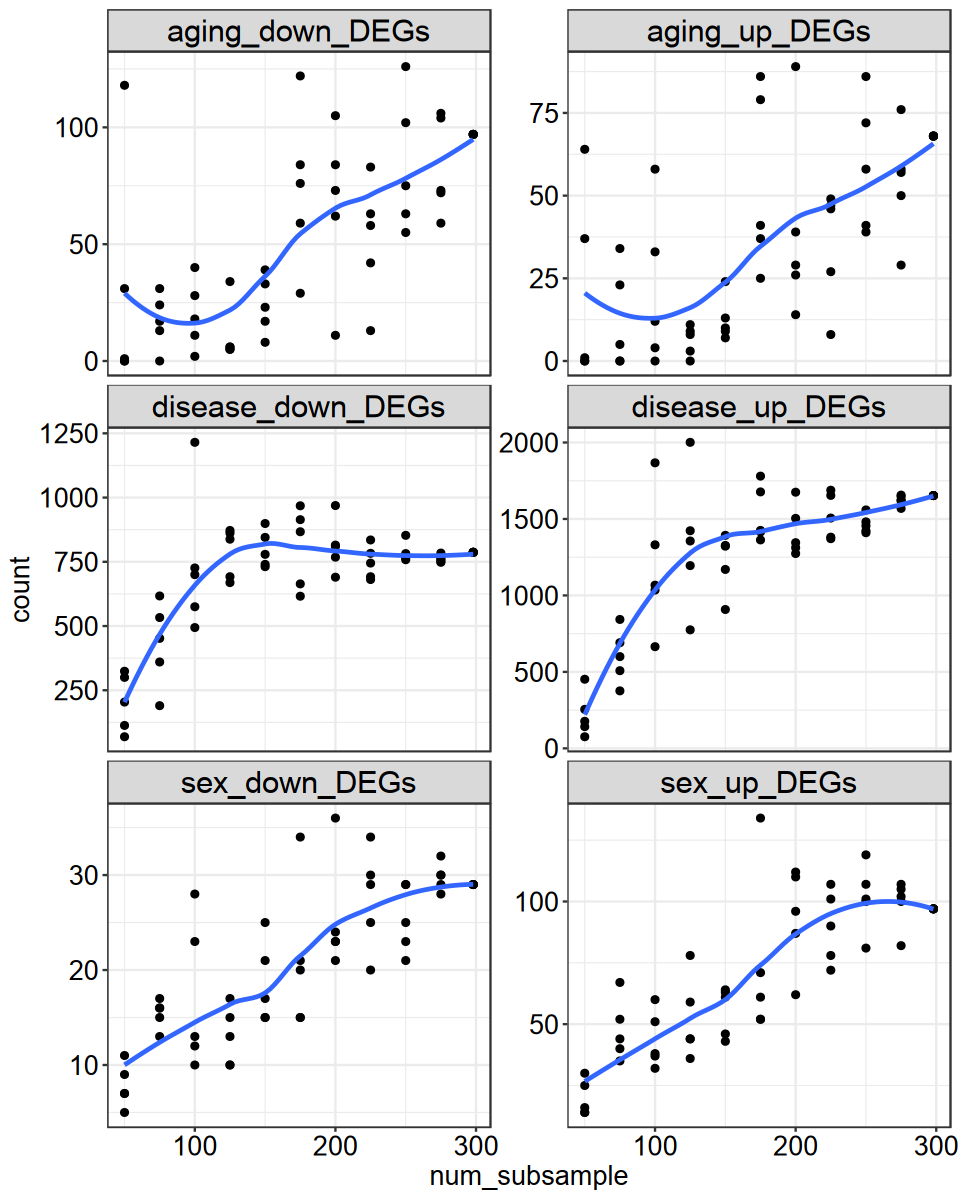

In [5]:
options(repr.plot.width = 8, repr.plot.height = 10)

# pivot long
long_results_df <- CM_subsampled_results_df %>%
  pivot_longer(cols = -c(num_subsample, replicate), names_to = "DEG_type", values_to = "count")

# generate the plot
p1 <- ggplot(data = long_results_df, mapping = aes(x = num_subsample, y = count)) +
  geom_point() +
  geom_smooth(method = "loess", se = FALSE) +
  facet_wrap(~DEG_type, scales = "free_y", ncol = 2) +  # Facet for each column
  theme_bw() +
  theme(
    legend.text = element_text(size = 16), 
    legend.title = element_text(size = 16, color = "black"), 
    plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
    axis.title.x = element_text(size = 16, color = "black"),
    axis.title.y = element_text(size = 16, color = "black"),
    axis.text.x = element_text(size = 16, color = "black"),
    axis.text.y = element_text(size = 16, color = "black"),
    strip.text = element_text(size = 18, color = "black")
  )

p1 

ggsave(p1, filename = paste0(plots_dir, "Cardiomyocyte_DEG_saturation_plot.pdf"), height = 10, width = 8)

### Fibroblast

In [6]:
Fibro_subsampled_results_df <- read.csv("Fibroblast_deg_results_subsampling.csv")
Fibro_subsampled_results_df %>% head()

,num_subsample,aging_up_DEGs,aging_down_DEGs,disease_up_DEGs,disease_down_DEGs,sex_up_DEGs,sex_down_DEGs,replicate
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,50,0,0,1148,1519,16,8,1
2,50,4,5,500,595,14,11,2
3,50,0,0,528,909,14,9,3
4,50,34,20,276,526,15,9,4
5,50,2,0,378,365,15,13,5
6,75,2,2,713,867,86,82,1


In [7]:
colnames(Fibro_subsampled_results_df)

[1] "num_subsample"     "aging_up_DEGs"     "aging_down_DEGs"  
[4] "disease_up_DEGs"   "disease_down_DEGs" "sex_up_DEGs"      
[7] "sex_down_DEGs"     "replicate"

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


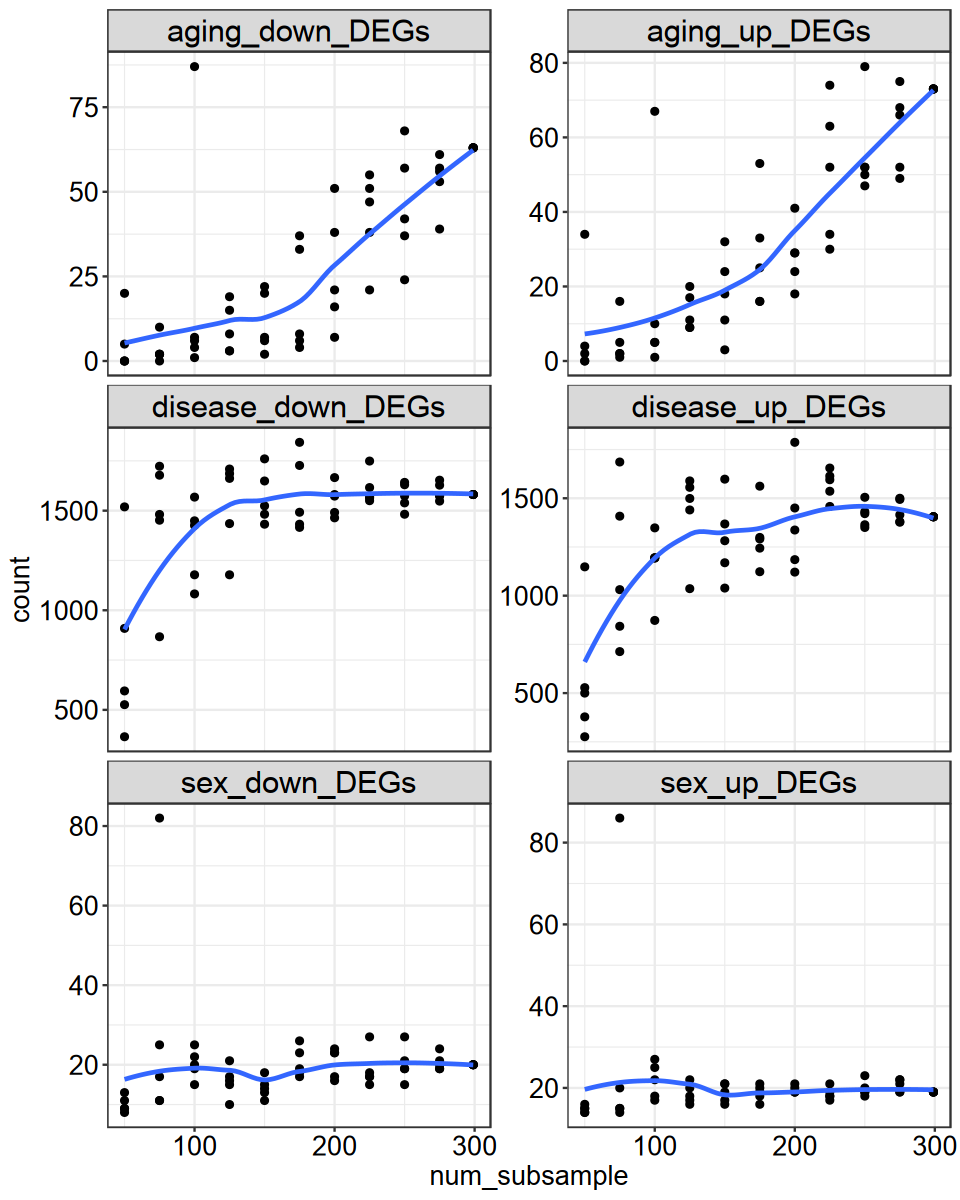

In [8]:
options(repr.plot.width = 8, repr.plot.height = 10)

# pivot long
long_results_df <- Fibro_subsampled_results_df %>%
  pivot_longer(cols = -c(num_subsample, replicate), names_to = "DEG_type", values_to = "count")

# generate the plot
p2 <- ggplot(data = long_results_df, mapping = aes(x = num_subsample, y = count)) +
  geom_point() +
  geom_smooth(method = "loess", se = FALSE) +
  facet_wrap(~DEG_type, scales = "free_y", ncol = 2) +  # Facet for each column
  theme_bw() +
  theme(
    legend.text = element_text(size = 16), 
    legend.title = element_text(size = 16, color = "black"), 
    plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
    axis.title.x = element_text(size = 16, color = "black"),
    axis.title.y = element_text(size = 16, color = "black"),
    axis.text.x = element_text(size = 16, color = "black"),
    axis.text.y = element_text(size = 16, color = "black"),
    strip.text = element_text(size = 18, color = "black")
  )

p2

ggsave(p2, filename = paste0(plots_dir, "Fibroblast_DEG_saturation_plot.pdf"), height = 10, width = 8)